# Python Discrete Control

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [2]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial et on crée le modèle de transfert avec TransferFunctionModel(). Ce modèle est ensuite utilisé par le simulateur de fonction de transfert.

In [3]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

Les paramètres de la simulation (temps total et période d'échantillonnage) se trouvent dans le fichier Models/BallBeam/ballbeam_config.py, mais ils peuvent être modifiés directement dans le notebook. Par défaut, la durée de simulation T est de 3 secondes et la période d'échantillonnage est de 20 ms.

In [4]:
#ballbeam_config.dt=0.1 

#### Réponse indicielle et impulsionnelle
Le but est de comparer notre simulation à celle de la librairie Python.

1) Réponse impulsionnelle

In [5]:
## simulateur 
impulse_logger=SimLog()
impulse_logger=run_discrete_impulse_response(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

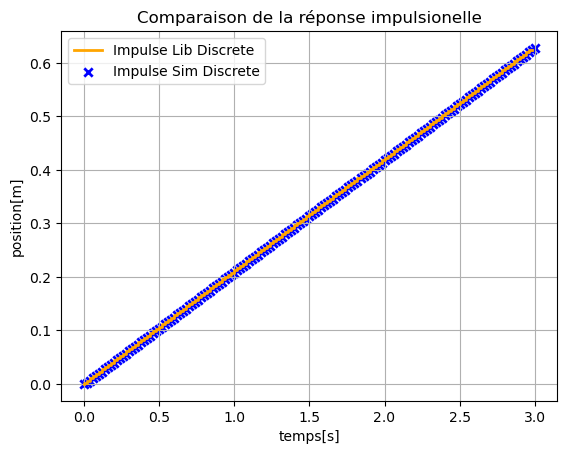

In [6]:
## affichage
fig1=plt.figure()
plt.step(
    t,
    y_lib,
    color='orange',
    linewidth=2,
    label="Impulse Lib Discrete"
)
plt.scatter(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    color='blue',
    marker='x',
    label="Impulse Sim Discrete",
    linewidth=2,
)


plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle
Ici aussi, on utilise les run... pour simuler la réponse inditielle. Pour cela, on créé une nouvelle instance de SimLog

In [7]:
## simulateur 
step_logger=SimLog()
step_logger=run_discrete_step_response(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [8]:
_, y_lib = ct.step_response(model.Tf_cont, t)

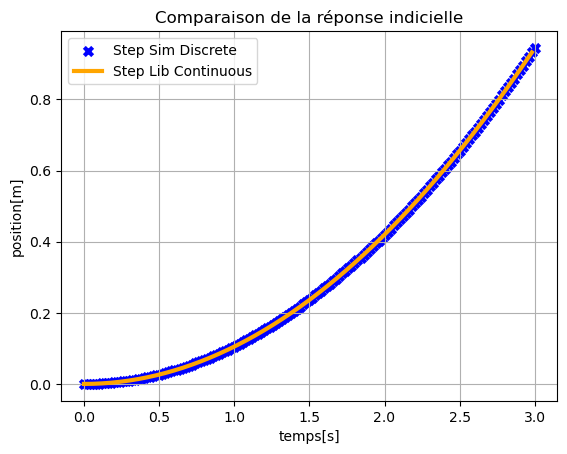

In [9]:
fig3=plt.figure()
plt.scatter(
    step_logger.t_hist,
    step_logger.y_hist,
    color='blue',
    marker='x',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    color='orange',
    linestyle='-',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Contrôle PID et validation


#### Mise en place du PID
On peut changer la duréé de simulation en mettant ballbeam_config.T= varaible . L'instance du PID discret est initalisé avec DiscretePID().

In [10]:
ballbeam_config.T=5

#### Modele en espace d'états (utilisé pour la simulation hybride)
Pour initailiser le simulateur continu, on lui met en entrée le ficher python contenant les matrices d'état 

In [11]:
StateSpace_Ball_Beam=LinearStateSpaceModel(ballbeam_config)
hybrid_loop=HybridSim(StateSpace_Ball_Beam,ballbeam_config)


La fonction run_continuous_step_response prends en entrée le simulateur continu, l'état initial du système, et l'enregistreur 

In [12]:
logger_hybrid_step = SimLog()
logger_hybrid_step = run_continuous_step_response(hybrid_loop, X_0,logger_hybrid_step)

In [13]:
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib1 = ct.step_response(model.Tf_cont, t)

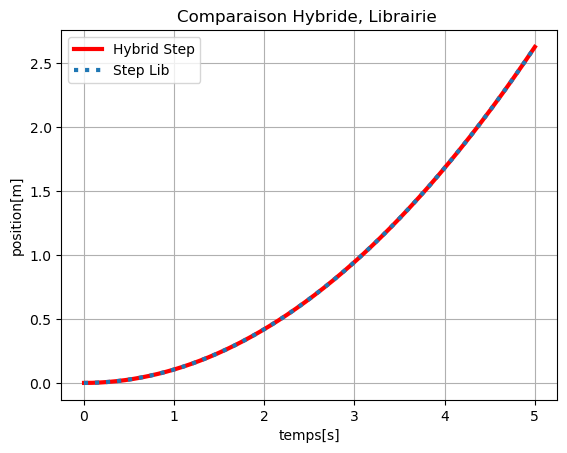

In [14]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

La boucle fermée hybride est simulée par run_continuous_control_loop(), tout contrôleur qui est mis en entrée de cette fonction doit avoir la méthode setReference() et step().
Pour configurer le PID, il lui faut l'initialiser avec ses paramètres.

In [15]:
kp, ki, kd = 40,60, 50
r = 1.0
PID = DiscretePID(kp,ki,kd,ballbeam_config.dt)
#PID.reset()

In [16]:
logger_hybrid = SimLog()
logger_hybrid = run_continuous_control_loop(hybrid_loop,PID,r,X_0,logger_hybrid,False,False)


In [17]:
L = PID.transferFunction * model.Tf_dis
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

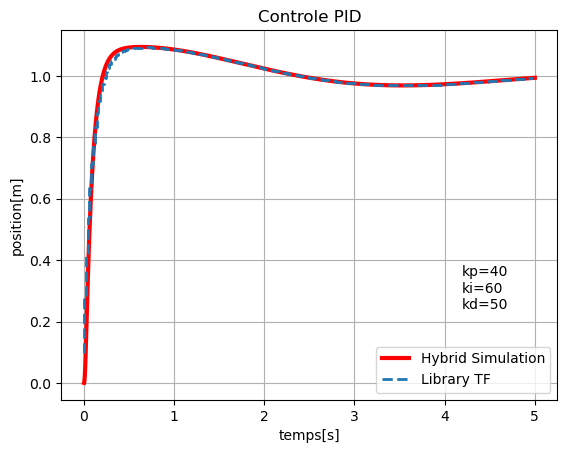

In [18]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


Outil pour exporter un enregistreur sous forme de fichier CSV

In [19]:
# Export helper already imported elsewhere in the notebook.
#utils.as_csv('hybridLog',logger_hybrid)

Contrôle RST, les polynômes R, S et T doivent être entrés dans RSTController() \
Ici, on a utilisé le PID discret changé en structure RST

In [20]:
rst=RSTController(PID.R,PID.S,PID.T)
logger_rst = SimLog()
logger_rst = run_continuous_control_loop(hybrid_loop,rst,r,X_0,logger_rst,False,False)

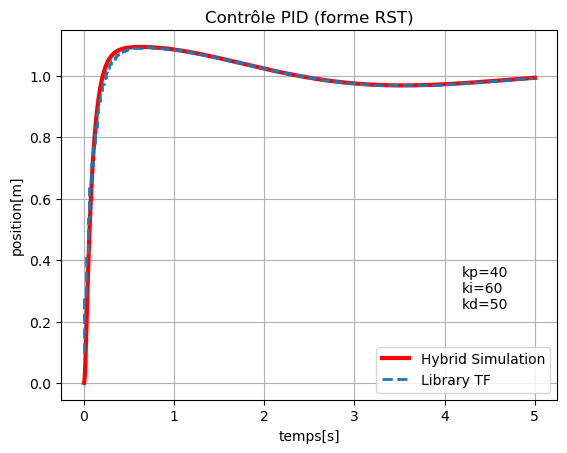

In [21]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Contrôle PID (forme RST)")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


In [22]:
logger_discrete_control=SimLog()
logger_discrete_control=run_discrete_control(plant_sim,rst,ballbeam_config,1.0,0,logger_discrete_control,False,False)

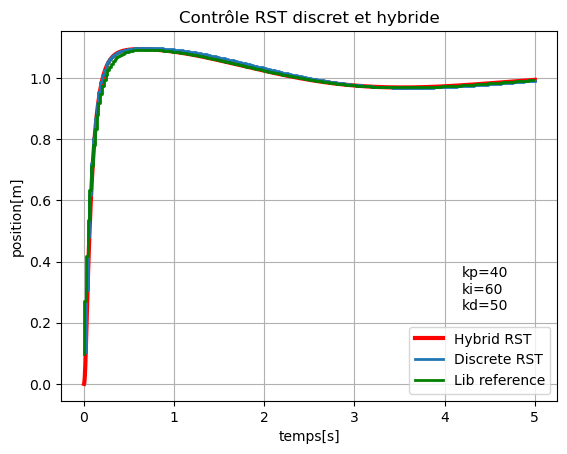

In [23]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid RST"
)
plt.step(logger_discrete_control.t_hist, logger_discrete_control.y_hist, label="Discrete RST",linewidth=2,
    linestyle='-',)
plt.step(t,y_lib,label="Lib reference",color="green",linewidth=2,
    linestyle='-',)
plt.title("Contrôle RST discret et hybride")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Comparaision_hybride_discret_simu.png')
plt.show()


In [24]:
from Utils import utils
from Utils import computeRST

RST avec fonction de transfert en BF désirée 

In [25]:
A_cl = [1, -1.2,0.5]
print(np.roots(A_cl))

[0.6+0.37416574j 0.6-0.37416574j]


In [26]:
S,R,T,H_cl=computeRST.Compute_Denominator_Matching_RST(A_cl,model.Tf_dis,False)


--- RST synthesis complete ---
S: [0.7875 0.1125]
R: [ 5059.52381582  1190.47617788 -2678.57142227]
T: [3571.42857143]

Exact closed-loop transfer function enforced by R,S,T:
Numerator coefficients: [0.15 0.15]
Denominator coefficients: [ 1.0000000e+00 -1.2000000e+00  5.0000000e-01  1.2490009e-16]
<TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

            0.15 z + 0.15
  ---------------------------------
  z^3 - 1.2 z^2 + 0.5 z + 1.249e-16
Closed-loop DC gain: 0.9999999999999984
Poles of the closed loop transfer function
z poles: [ 6.00000000e-01+0.37416574j  6.00000000e-01-0.37416574j
 -2.49800181e-16+0.j        ]
radius: [7.07106781e-01 7.07106781e-01 2.49800181e-16]


In [27]:
rst_2=RSTController(R,S,T)
logger_rst_test = SimLog()
logger_rst_test = run_discrete_control(plant_sim,rst_2,ballbeam_config,1.0,0.0,logger_rst_test,False,False)

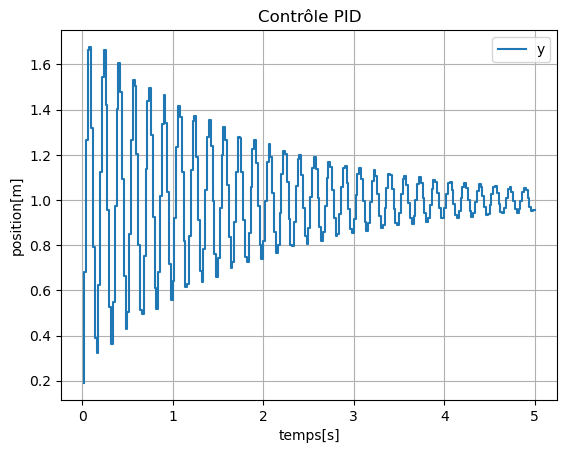

In [ ]:
plt.figure()
plt.step(logger_rst_test.t_hist, logger_rst_test.y_hist, label="y")
#plt.plot(logger_rst_test.t_hist, logger_rst_test.u_hist, label="u")
plt.title("Contrôle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()

In [29]:
utils.as_csv('RSTLog',logger_rst_test)

In [30]:

plant = TransferFunctionModel(ballbeam_config)

Desired_TF=utils.Place_real_radius(plant.Tf_dis,0.95,1.0)
print('Plant TF:')
print(plant.Tf_dis)
print('\nDesired TF:')
print(Desired_TF)

# Run synthesis using your existing Compute_Desired_RST
S_tf, R_tf, T_tf,H_cl = computeRST.Compute_Desired_RST(Desired_TF, plant.Tf_dis)
print('\nS =', S_tf)
print('R =', R_tf)
print('T =', T_tf)


Plant TF:
<TransferFunction>: sys[28]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  4.2e-05 z + 4.2e-05
  -------------------
     z^2 - 2 z + 1

Desired TF:
<TransferFunction>: sys[30]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

        6.25e-05 z + 6.25e-05
  ---------------------------------
  z^3 - 2.85 z^2 + 2.708 z - 0.8574

--- RST synthesis complete ---
S: [ 0.92685937 -0.92685937]
R: [ 1741.44345238 -3394.3452381   1654.38988095]
T: [1.48809524]

Closed-loop TF check:
<TransferFunction>: sys[34]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

        6.25e-05 z + 6.25e-05
  ---------------------------------
  z^3 - 2.85 z^2 + 2.708 z - 0.8574
1.000000000004441
Poles of the closed loop transfer function
z poles: [0.95000571+0.00000000e+00j 0.94999715+4.94367469e-06j
 0.94999715-4.94367469e-06j]
radius: [0.95000571 0.94999715 0.94999715]

S = <TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  0.9269 z - 0.9269
  

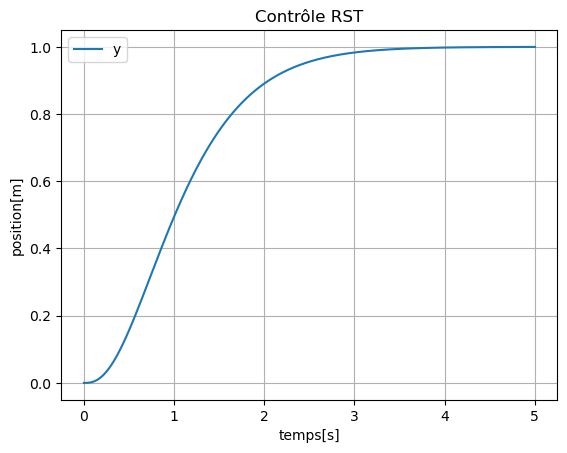

In [31]:
rst_3=RSTController(R_tf,S_tf,T_tf)
logger_rst_4 = SimLog()
logger_rst_4 = run_continuous_control_loop(hybrid_loop,rst_3,1.0,X_0,logger_rst_4,False,False)
plt.figure()
plt.plot(logger_rst_4.t_hist, logger_rst_4.y_hist, label="y")


plt.title("Contrôle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


In [32]:

j=complex(0,1)
poles=[0.8,0.8-0.2*j,0.82+0.2*j]
A_cl=utils.poles_to_denominator(poles)

S,R,T,H_cl=computeRST.Compute_Denominator_Matching_RST(A_cl,model.Tf_dis,True)
rst_3=RSTController(R,S,T)
logger_rst_3 = SimLog()
logger_rst_3 = run_discrete_control(plant_sim,rst_3,ballbeam_config,1.0,0.0,logger_rst_3,False,False)


--- RST synthesis complete ---
S: [ 0.7461 -0.7461]
R: [  6045.23809523 -10371.42857142   4507.14285714]
T: [180.95238095]

Exact closed-loop transfer function enforced by R,S,T:
Numerator coefficients: [0.0076 0.0076]
Denominator coefficients: [ 1.     -2.42    1.992  -0.5568]
<TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

          0.0076 z + 0.0076
  ---------------------------------
  z^3 - 2.42 z^2 + 1.992 z - 0.5568
Closed-loop DC gain: 1.0000000000001024
Poles of the closed loop transfer function
z poles: [0.81+0.19974984j 0.81-0.19974984j 0.8 +0.j        ]
radius: [0.83426614 0.83426614 0.8       ]


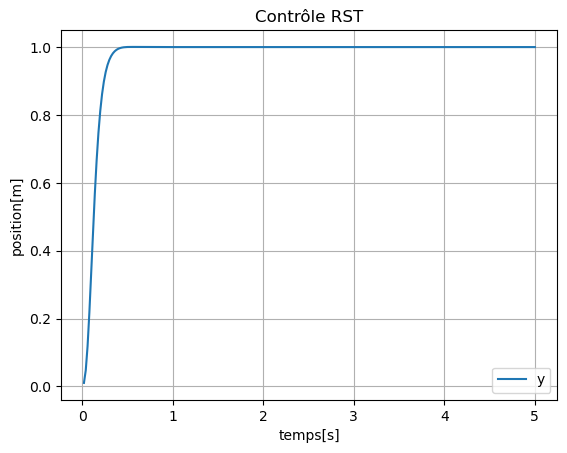

In [33]:
plt.figure()
plt.plot(logger_rst_3.t_hist, logger_rst_3.y_hist, label="y")
#plt.plot(logger_rst_3.t_hist, logger_rst_3.u_hist, label="u")
plt.title("Contrôle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()
